# Fault Subsections

This notebook demonstrates subsection-level view classes. Topics covered:

1. Creating a `FaultSubsection` facade
2. `FaultSubsectionData` — subsection attributes
3. `FaultSubsectionRuptures` — rupture participation and cumulative MFD
4. Direct instantiation of `FaultSubsectionData` and `FaultSubsectionRuptures`

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from parserf.models import FaultModel, FaultModelDataset
from parserf.queries import get_nearest_subsection_index
from parserf.subsection import FaultSubsection, FaultSubsectionData, FaultSubsectionRuptures

In [2]:
ds = FaultModelDataset(FaultModel.NSHMP_2023)
idx = get_nearest_subsection_index(ds, lat=35.77, lon=-117.60)
print("Nearest subsection index:", idx)

Nearest subsection index: 3276


## 1. FaultSubsection Facade

`FaultSubsection` validates the index and exposes `.data` and `.ruptures`.

In [3]:
sub = FaultSubsection(ds, index=idx)
print(sub)

FaultSubsection(fault_model=NSHMP_2023, index=3276, name='Paxton Ranch (4)')


## 2. FaultSubsectionData

Properties for a single subsection's attributes.

In [4]:
print("Index:       ", sub.data.index)
print("Name:        ", sub.data.name)
print("Parent ID:   ", sub.data.parent_id)
print("Parent Name: ", sub.data.parent_name)

Index:        3276
Name:         Paxton Ranch (4)
Parent ID:    331
Parent Name:  Paxton Ranch


In [5]:
print("Geometry:    ", sub.data.geometry)
print("Length (km): ", round(sub.data.length_km, 3))
print("Width (km):  ", round(sub.data.width_km, 3))
print("Area (km\u00b2):  ", round(sub.data.area_km2, 3))

Geometry:     LINESTRING (-117.5922 35.75226, -117.6008 35.76561, -117.6137 35.79066, -117.6182 35.80999, -117.62081 35.81262)
Length (km):  7.245
Width (km):   15.0
Area (km²):   108.682


In [6]:
print("Upper depth (km):  ", sub.data.upper_depth_km)
print("Lower depth (km):  ", sub.data.lower_depth_km)
print("Dip (degrees):     ", sub.data.dip)
print("Dip direction:     ", sub.data.dip_direction)
print("Aseismicity:       ", sub.data.aseismicity)

Upper depth (km):   0.0
Lower depth (km):   15.0
Dip (degrees):      90.0
Dip direction:      49.0
Aseismicity:        0.1


## 3. FaultSubsectionRuptures

Rupture participation data for a single subsection.

### participating_ruptures

GeoDataFrame of all rupture scenarios involving this subsection, enriched with merged
geometry, total length/area, and parent fault area percentages. The data is in exploded
form: one row per (rupture, parent) pair with `parent_id` and `area_pct` columns.

In [7]:
rups = sub.ruptures.participating_ruptures
unique_count = rups.index.nunique()
print(f"{len(rups)} rows ({unique_count} unique ruptures)")
print("Columns:", list(rups.columns))
rups.head()

10042 rows (1726 unique ruptures)
Columns: ['m', 'rate', 'depth', 'dip', 'width', 'rake', 'geometry', 'length_km', 'area_km2', 'parent_id', 'area_pct']


,m,rate,depth,dip,width,rake,geometry,length_km,area_km2,parent_id,area_pct
99,6.89,1.877045e-11,1.410,72.0,14.298,-139.0,"MULTILINESTRING ((-117.74953 35.74054, -117.76...",37.461521,592.869358,331,55.041543
99,6.89,1.877045e-11,1.410,72.0,14.298,-139.0,"MULTILINESTRING ((-117.74953 35.74054, -117.76...",37.461521,592.869358,1,44.958457
100,6.97,0.000000e+00,1.424,74.8,14.174,-145.0,"MULTILINESTRING ((-117.74953 35.74054, -117.76...",44.723407,701.797658,331,62.019691
100,6.97,0.000000e+00,1.424,74.8,14.174,-145.0,"MULTILINESTRING ((-117.74953 35.74054, -117.76...",44.723407,701.797658,1,37.980309
101,7.04,3.366303e-06,1.434,76.8,14.084,-149.0,"MULTILINESTRING ((-117.74953 35.74054, -117.76...",51.979265,810.635524,331,67.119019


In [8]:
# Examine parent area breakdown for one rupture
# Get the last unique rupture (may have multiple rows, one per parent)
last_rup_idx = rups.index[-1]
rup_rows = rups.loc[[last_rup_idx]]
first_row = rup_rows.iloc[0]
print("Length (km):       ", round(first_row["length_km"], 2))
print("Area (km²):       ", round(first_row["area_km2"], 2))
print("Geometry type:     ", first_row["geometry"].geom_type)
print("Parent area breakdown:")
for _, r in rup_rows.iterrows():
    pid = int(r["parent_id"])
    pname = ds.subsections.loc[ds.subsections["parent_id"] == pid, "parent_name"].iloc[0]
    print(f"  {pname} (id={pid}): {r['area_pct']:.1f}%")

Length (km):        272.82
Area (km²):        4348.68
Geometry type:      MultiLineString
Parent area breakdown:
  Sierra Nevada (north) (id=277): 3.5%
  Sierra Nevada (south) (id=278): 17.6%
  Paxton Ranch (id=331): 15.0%
  Owens Valley (id=199): 33.5%
  South Mono (proxy) (id=350): 23.6%
  Owens Valley (Keough Hot Springs) (id=200): 6.7%


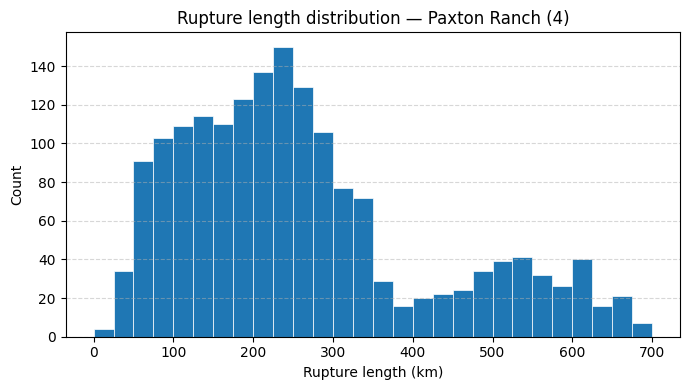

In [9]:
# Rupture length distribution (deduplicate exploded rows)
unique_rups = rups[~rups.index.duplicated()]
bin_width = 25
lengths = unique_rups["length_km"]
bins = np.arange(0, lengths.max() + bin_width, bin_width)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lengths, bins=bins, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Rupture length (km)")
ax.set_ylabel("Count")
ax.set_title(f"Rupture length distribution \u2014 {sub.data.name}")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### cumulative_mfd

Cumulative magnitude frequency distribution (exceedance rates).

In [10]:
mfd = sub.ruptures.cumulative_mfd
mfd

,magnitude,cumulative_rate
0,6.42,0.000405
1,6.61,0.000376
2,6.69,0.000340
3,6.75,0.000340
4,6.78,0.000315
...,...,...
125,8.07,0.000004
126,8.08,0.000004
127,8.09,0.000004
128,8.10,0.000004


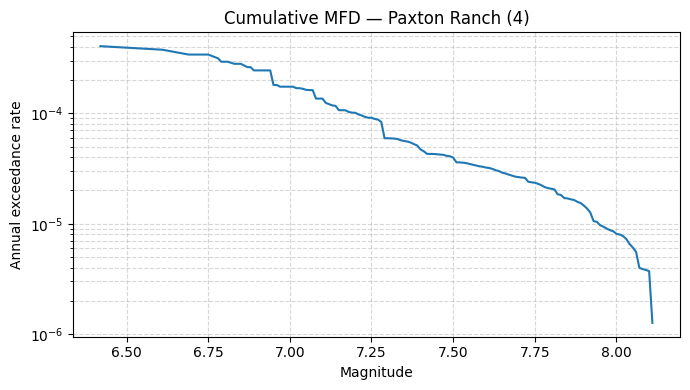

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(mfd["magnitude"], mfd["cumulative_rate"], linewidth=1.5)
ax.set_xlabel("Magnitude")
ax.set_ylabel("Annual exceedance rate")
ax.set_title(f"Cumulative MFD \u2014 {sub.data.name}")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Direct Instantiation

`FaultSubsectionData` and `FaultSubsectionRuptures` can be used standalone
without going through the `FaultSubsection` facade.

In [12]:
data = FaultSubsectionData(ds, index=idx)
print("Name:", data.name)
print("Length (km):", round(data.length_km, 3))

Name: Paxton Ranch (4)
Length (km): 7.245


In [13]:
ruptures = FaultSubsectionRuptures(ds, index=idx)
print("Participating ruptures:", len(ruptures.participating_ruptures))

Participating ruptures: 10042
